## Imports

In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalMaxPool2D,
)
from tensorflow.keras.applications import ResNet50V2

In [12]:
%matplotlib inline

In [13]:
print(tf.config.list_physical_devices("GPU"))

[]


## Utils

In [14]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## EDA

In [15]:
dataset_dir = "../data/dogs_vs_cats"
train_dir = f"{dataset_dir}/train"
test_dir = f"{dataset_dir}/test"

In [16]:
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(224, 224), batch_size=32
)

print("\nLoading Test/Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(224, 224), batch_size=32
)

Loading Training Data:
Found 20000 files belonging to 2 classes.

Loading Test/Validation Data:
Found 5000 files belonging to 2 classes.


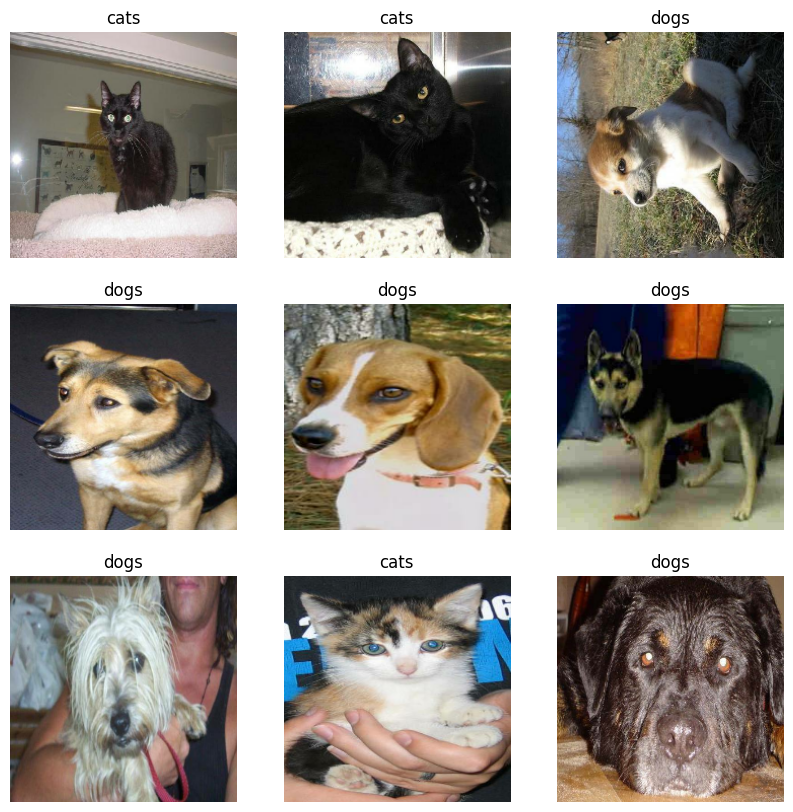

In [17]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [18]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(height_factor=(-0.3, -0.2)),
    ]
)

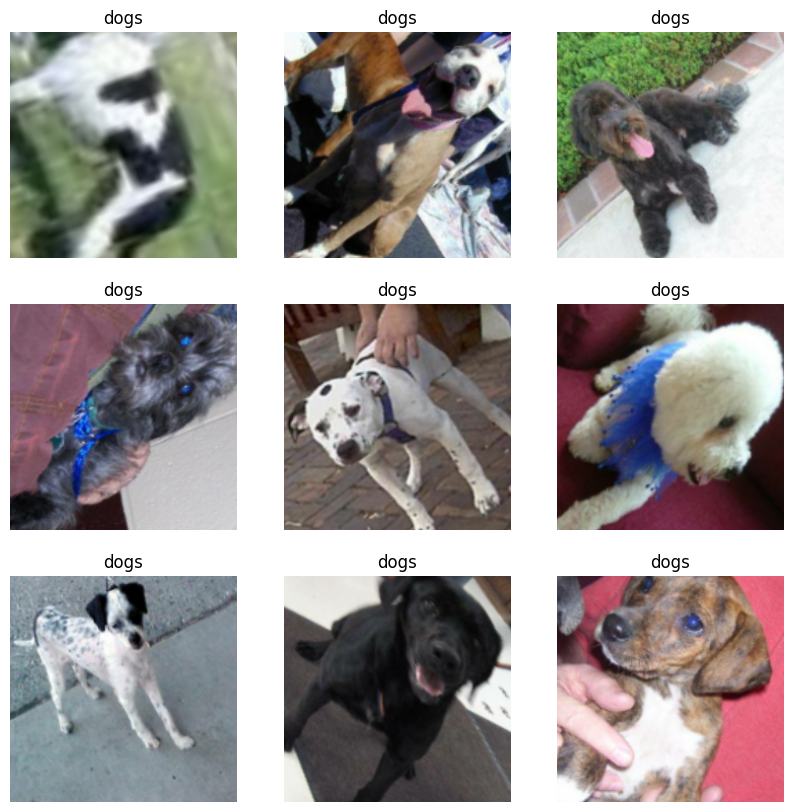

In [19]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## CNN

In [20]:
model = Sequential()

# Input
model.add(tf.keras.Input(shape=(224, 224, 3)))

# Block 1
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Classification Layer
model.add(GlobalMaxPool2D())
model.add(Dense(units=128))
model.add(Activation("relu"))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.add(Activation("sigmoid"))

model.summary()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

Epoch 1/10
229/625 ━━━━━━━━━━━━━━━━━━━━ 3:48 577ms/step - accuracy: 0.5032 - loss: 3.6156

In [ ]:
loss, accuracy = model.evaluate(val_dataset)
print(f"Validation Accuracy: {accuracy*100:.2f}%")

In [ ]:
plot_history(history, title="CNN Model Performance")

In [ ]:
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False 

resnet_model = Sequential()

resnet_model.add(base_model)

resnet_model.add(GlobalMaxPool2D())
resnet_model.add(Dense(units=128))
resnet_model.add(Activation("relu"))
resnet_model.add(Dropout(0.2))
resnet_model.add(Dense(units=1))
resnet_model.add(Activation("sigmoid"))

resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
print("Training ResNet50 Comparison Model...")
history_resnet = resnet_model.fit(train_dataset, validation_data=val_dataset, epochs=3) 

In [ ]:
loss, accuracy = resnet_model.evaluate(val_dataset)
print(f"ResNet Validation Accuracy: {accuracy*100:.2f}%")